# Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.datasets import make_blobs
import pathlib
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from kneed import KneeLocator

# Data Creation

In [21]:
x,y=make_blobs(n_samples=1200,n_features=2,centers=3)

In [22]:
x.shape

(1200, 2)

In [23]:
x

array([[ 5.35381692, -7.47531829],
       [ 2.5607143 ,  4.45125928],
       [-2.92304244, -5.88432893],
       ...,
       [ 5.79972786, -8.12891676],
       [-0.71759688, -7.45272812],
       [ 3.9631976 ,  3.00339857]])

In [24]:
y.shape

(1200,)

In [25]:
y

array([2, 1, 0, ..., 2, 0, 1])

# Basic Plot

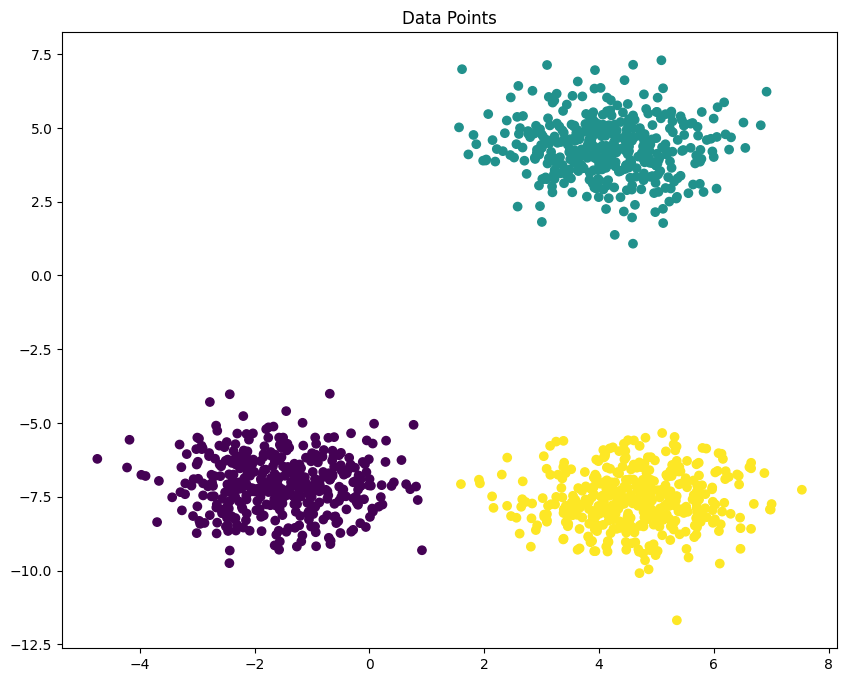

In [26]:
plt.figure(figsize=(10,8))
plt.scatter(x[:,0],x[:,1],c=y)
plt.title('Data Points')
plt.savefig('Basic Plot.png')
plt.show()

# Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

# Model Traing

In [28]:
wcss=[]
for i in range(1,20):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [29]:
wcss

[32159.63173309817,
 6760.007849625361,
 1541.4044715909195,
 1383.1643587133221,
 1191.765504024996,
 1090.5021892547288,
 923.4524064051674,
 814.2379612637362,
 759.7999187594462,
 673.4547922404613,
 612.7318912069836,
 571.4402052656894,
 523.2665213623509,
 488.38326578254816,
 455.760543796369,
 418.47660157115615,
 393.79254137417036,
 398.5340193803779,
 349.55007768116184]

# Plot Wcss

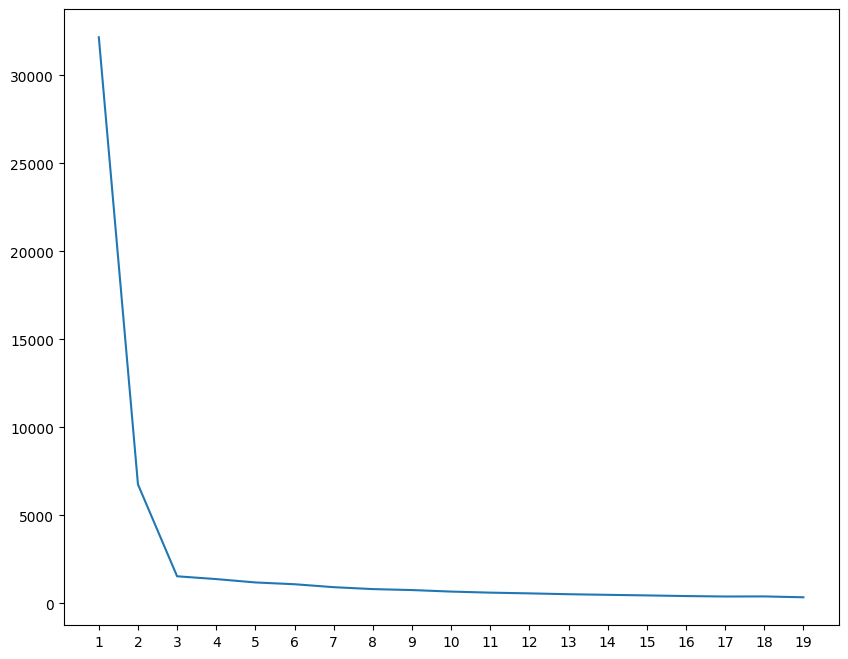

In [30]:
plt.figure(figsize=(10,8))
plt.plot(range(1,20),wcss)
plt.xticks(range(1,20))
plt.savefig('WCSS plot.png')
plt.show()

In [31]:
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit(X_train)

KMeans(n_clusters=3)

# Prediction

In [32]:
y_pred=kmeans.predict(X_test)

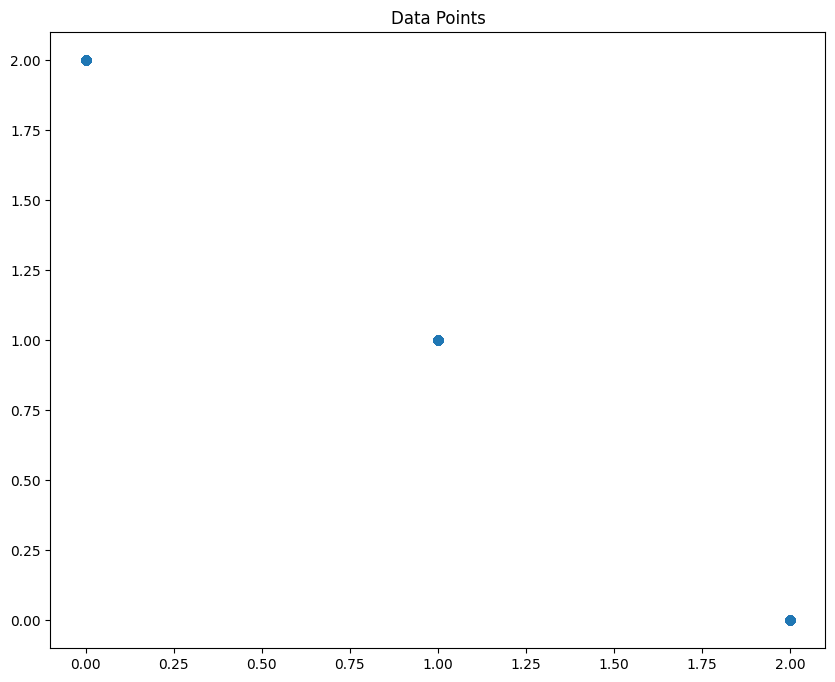

In [33]:
indices = np.arange(len(y_test))
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred)
plt.title('Data Points')
plt.savefig('Predicted Plot.png')
plt.show()

# Kneed Locator

In [34]:
kl=KneeLocator(range(1,20),wcss,curve='convex',direction='decreasing')

In [35]:
kl.elbow

np.int64(3)